# 04 — Visualization: Winning Configuration Across Walk-Forward CV Folds

Under the old single-80/20-split pipeline this notebook compared the top-3 model
configurations on one fixed test window. Under the revised walk-forward design there's
no single split to compare against -- instead this plots the **single winning
configuration** from `02c_model_selection_cv.ipynb` / `02d_nested_tuning_cv.ipynb`
across each of its 5 outer CV folds, using the production hyperparameters. This
directly surfaces which folds coincide with the regime-shift flags (2020 COVID crash,
2022 rate-hike cycle) for discussion, rather than hiding fold-to-fold variance behind
a single averaged number.


In [1]:
import glob
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import cv_lib as cv

df_merged = joblib.load(sorted(glob.glob("saved_models/df_merged_*.joblib"), reverse=True)[0])
TUNING = joblib.load("saved_models/optuna_tuning_results.joblib")
final_config = joblib.load("saved_models/final_config.joblib")
df_outer = pd.read_csv("nested_cv_outer_fold_results.csv")

MODEL_NAME = final_config["model"]
COV_VARS = final_config["cov_vars"]
WINDOW = final_config["window"]
HORIZON = final_config["horizon"]
PROD_TRAIN_END = final_config["production_train_end"]

print(f"Winning configuration: {MODEL_NAME} | {final_config['covariates']} | W{WINDOW}_H{HORIZON}")
print(f"Production hyperparameters: {TUNING[MODEL_NAME]['best_params']}")

target_ts, cov_ts = cv.to_series(df_merged, "IHSG", COV_VARS)
n = len(target_ts)
outer_folds = cv.expanding_window_folds(n, n_folds=len(df_outer), embargo=HORIZON)
assert len(outer_folds) == len(df_outer), "rebuilt outer folds don't match nested_cv_outer_fold_results.csv"
print(f"{len(outer_folds)} outer folds rebuilt, matching Stage B's fold count.")

Winning configuration: ExtraTrees | Screening1 | W120_H1
Production hyperparameters: {'n_estimators': 800, 'max_depth': 12, 'max_features': 0.7, 'min_samples_split': 3, 'min_samples_leaf': 10}
5 outer folds rebuilt, matching Stage B's fold count.


## Retrain and predict per outer fold

Uses the single production hyperparameter set (from `saved_models/optuna_tuning_results.joblib`)
refit on each fold's own `train_end` -- i.e. what the final model would have predicted at
each point in the walk-forward evaluation, respecting each fold's own information cutoff.


In [2]:
best_params = TUNING[MODEL_NAME]["best_params"].copy()
fold_predictions = []

for f in outer_folds:
    dates, actual, predicted = cv.predict_fold(
        MODEL_NAME, best_params, target_ts, cov_ts, WINDOW, HORIZON,
        f["train_end"], f["test_start"], f["test_end"],
    )
    row = df_outer[df_outer["Fold"] == f["fold"]].iloc[0]
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    fold_predictions.append({
        "fold": f["fold"], "dates": pd.to_datetime(dates), "actual": actual, "predicted": predicted,
        "regime_flags": row["regime_flags"], "mape": mape,
    })
    print(f"Fold {f['fold']}: {len(dates)} points, MAPE={mape:.4f}%"
          + (f"  [REGIME: {row['regime_flags']}]" if pd.notna(row['regime_flags']) else ""))

Fold 0: 389 points, MAPE=0.8085%  [REGIME: covid_crash]


Fold 1: 389 points, MAPE=0.7789%  [REGIME: covid_crash]


Fold 2: 389 points, MAPE=0.5741%  [REGIME: rate_hike_cycle_2022]


Fold 3: 389 points, MAPE=0.4749%  [REGIME: rate_hike_cycle_2022]


Fold 4: 389 points, MAPE=0.5439%


## Plot 1 — Actual vs. predicted, one panel per outer fold

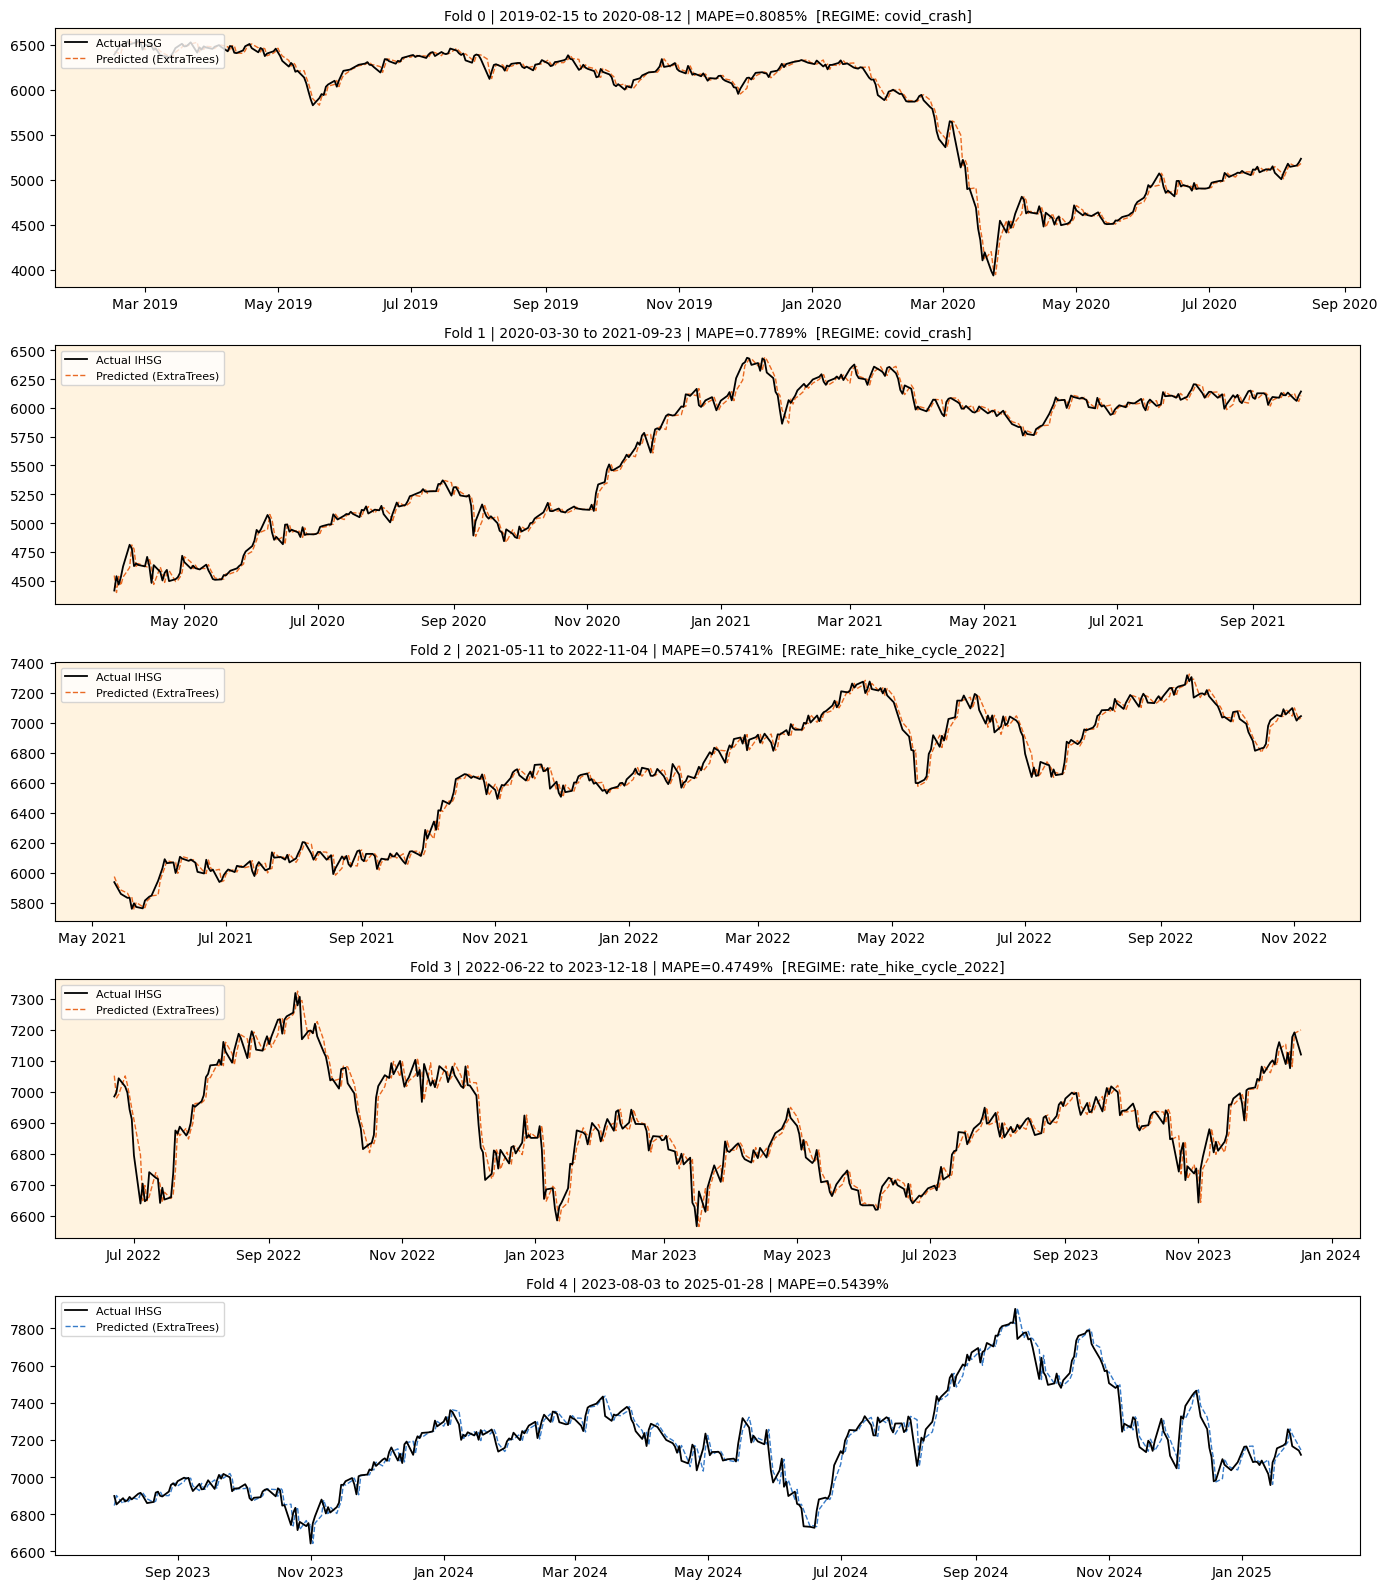

Saved: plot_winning_config_per_fold.png


In [3]:
fig, axes = plt.subplots(len(fold_predictions), 1, figsize=(14, 3.2 * len(fold_predictions)), sharex=False)
if len(fold_predictions) == 1:
    axes = [axes]

for ax, fp in zip(axes, fold_predictions):
    flagged = pd.notna(fp["regime_flags"])
    ax.plot(fp["dates"], fp["actual"], color="black", linewidth=1.3, label="Actual IHSG", zorder=5)
    ax.plot(fp["dates"], fp["predicted"], color="#E65100" if flagged else "#1565C0",
            linewidth=1.0, linestyle="--", alpha=0.85, label=f"Predicted ({MODEL_NAME})")
    title = f"Fold {fp['fold']} | {fp['dates'].min().date()} to {fp['dates'].max().date()} | MAPE={fp['mape']:.4f}%"
    if flagged:
        title += f"  [REGIME: {fp['regime_flags']}]"
        ax.set_facecolor("#fff3e0")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
fig.savefig("plot_winning_config_per_fold.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plot_winning_config_per_fold.png")

## Plot 2 — Scatter: actual vs. predicted, colored by fold

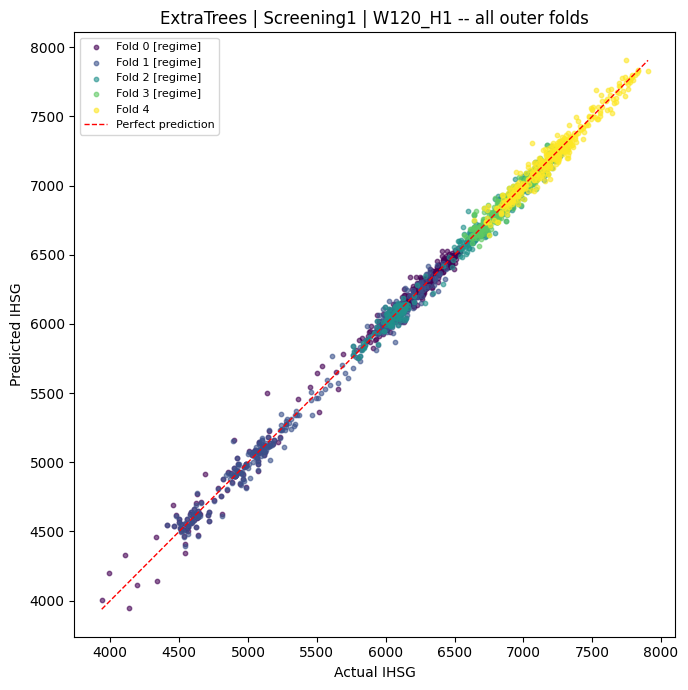

Saved: plot_winning_config_scatter.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
cmap = plt.get_cmap("viridis")
for i, fp in enumerate(fold_predictions):
    ax.scatter(fp["actual"], fp["predicted"], s=10, alpha=0.6,
               color=cmap(i / max(1, len(fold_predictions) - 1)),
               label=f"Fold {fp['fold']}" + (" [regime]" if pd.notna(fp["regime_flags"]) else ""))

all_actual = np.concatenate([fp["actual"] for fp in fold_predictions])
lims = [all_actual.min(), all_actual.max()]
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual IHSG")
ax.set_ylabel("Predicted IHSG")
ax.set_title(f"{MODEL_NAME} | {final_config['covariates']} | W{WINDOW}_H{HORIZON} -- all outer folds")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
fig.savefig("plot_winning_config_scatter.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plot_winning_config_scatter.png")

## Publication figure — final (production) fold

Same IEEE two-column formatting as the old notebook's publication figure, but sourced
from the **last** outer fold -- the same out-of-sample window `03_shap_analysis.ipynb`
computes SHAP on -- rather than a fixed 80/20 split.


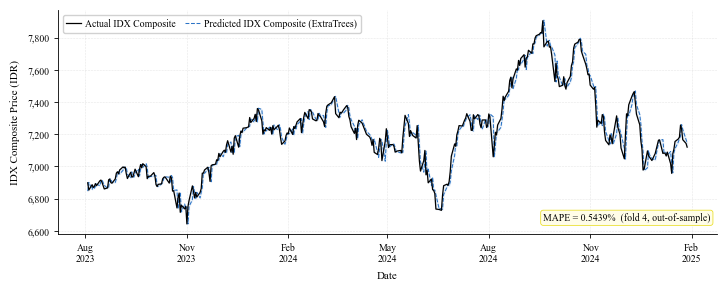

Saved: plot_pub_winning_config.png (600 dpi), plot_pub_winning_config_preview.png (150 dpi)
MAPE: 0.5439%


In [5]:
import matplotlib.ticker as mticker

IEEE_WIDTH, IEEE_HEIGHT, IEEE_DPI, FONT_PT = 7.16, 2.8, 600, 8

plt.rcParams.update({
    "font.family": "Times New Roman", "font.size": FONT_PT,
    "axes.titlesize": FONT_PT, "axes.labelsize": FONT_PT,
    "xtick.labelsize": FONT_PT - 1, "ytick.labelsize": FONT_PT - 1,
    "legend.fontsize": FONT_PT - 1, "lines.linewidth": 0.9, "axes.linewidth": 0.6,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.4, "grid.linestyle": "--",
    "legend.framealpha": 0.9, "legend.edgecolor": "#cccccc",
})

final_fp = fold_predictions[-1]
dates, actual, pred = final_fp["dates"], final_fp["actual"], final_fp["predicted"]
mape = final_fp["mape"]

fig, ax = plt.subplots(figsize=(IEEE_WIDTH, IEEE_HEIGHT))
ax.plot(dates, actual, color="#000000", linewidth=0.9, label="Actual IDX Composite", zorder=5)
ax.plot(dates, pred, color="#1565C0", linewidth=0.75, linestyle="--", alpha=0.9,
        label=f"Predicted IDX Composite ({MODEL_NAME})", zorder=4)
ax.fill_between(dates, actual, pred, alpha=0.07, color="#1565C0")
ax.set_ylabel("IDX Composite Price (IDR)", labelpad=5)
ax.set_xlabel("Date", labelpad=5)
ax.legend(loc="upper left", ncol=2, columnspacing=1.0, handlelength=1.5, handletextpad=0.4)
ax.annotate(f"MAPE = {mape:.4f}%  (fold {final_fp['fold']}, out-of-sample)",
            xy=(0.99, 0.05), xycoords="axes fraction", ha="right", va="bottom", fontsize=FONT_PT - 1,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="#fffde7", edgecolor="#e6d800", linewidth=0.5, alpha=0.95))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis="both", length=3, pad=3)
plt.tight_layout(pad=0.4)

fig.savefig("plot_pub_winning_config.png", dpi=IEEE_DPI, bbox_inches="tight", facecolor="white")
fig.savefig("plot_pub_winning_config_preview.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: plot_pub_winning_config.png (600 dpi), plot_pub_winning_config_preview.png (150 dpi)")
print(f"MAPE: {mape:.4f}%")